# Wound-Only Segmentation Baseline — Main Training Notebook

**Objective:** Establish a clean, reproducible Mask R-CNN baseline for wound-only
instance segmentation. Single target class: `wound` (+ background).

**Dataset:** `data/wound_focus_clean/` with pre-built train / val / test splits.

**Outputs:** checkpoints, training curves, COCO metrics, qualitative predictions,
and markdown reports — all under `experiments/maskrcnn/`.


## 1: Setup / Imports / Configuration


In [1]:
%matplotlib inline

import json
import sys
import time
import platform
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

SCRIPT_DIR = Path.cwd().resolve()
PROJECT_ROOT = SCRIPT_DIR.parent.parent
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if (SCRIPTS_DIR / "augmentation_strategy.py").exists():
    sys.path.insert(0, str(SCRIPTS_DIR))
sys.path.insert(0, str(SCRIPT_DIR))

from pipeline_utils import (
    set_seed,
    get_device,
    create_dataset,
    make_dataloaders,
    WOUND_ONLY_CLASSES,
)
from train_model import (
    build_model,
    train_one_epoch,
    validate_one_epoch,
    evaluate_metrics,
    save_best_checkpoint,
    save_last_checkpoint,
    load_checkpoint,
    validate_dataset_labels,
    predict_single_image,
    predict_image,
    visualize_prediction,
    calculate_wound_area,
    save_qualitative_predictions,
    save_training_curves,
    save_ap_curves,
    generate_wound_only_report,
    validate_wound_dataset,
    MEAN as IMG_MEAN,
    STD as IMG_STD,
)
try:
    from train_model import display_results_curves, display_results_predictions
except ImportError:
    def display_results_curves(results_dir, max_show=2):
        pass  # No-op when not available
    def display_results_predictions(results_dir, n_show=8):
        pass  # No-op when not available

print("=" * 60)
print("Libraries imported successfully")
print("=" * 60)
print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
print("=" * 60)

# ---------------------------------------------------------------------------
# Wound-only configuration (mirrors train_model.py)
# ---------------------------------------------------------------------------
CONFIG = {
    "data_root": str(PROJECT_ROOT / "data" / "wound_focus_clean"),
    "ann_file_train": str(PROJECT_ROOT / "data" / "wound_focus_clean" / "train_wound_only.json"),
    "ann_file_val": str(PROJECT_ROOT / "data" / "wound_focus_clean" / "val_wound_only.json"),
    "ann_file_test": str(PROJECT_ROOT / "data" / "wound_focus_clean" / "test_wound_only.json"),
    "output_dir": str(SCRIPT_DIR / "checkpoints"),
    "results_dir": str(SCRIPT_DIR / "results"),
    "reports_dir": str(SCRIPT_DIR / "reports"),
    "seed": 42,
    "batch_size": 2,
    "num_workers": 0 if platform.system() == "Windows" else 4,
    "epochs": 50,
    "lr": 0.001,
    "image_size": (512, 512),
    "early_stop_patience": 12,
    "early_stop_min_delta": 0.003,
    "loss_clip_max": 100.0,
    "loss_skip_threshold": 1000.0,
    "skip_invalid_targets": True,
    "device_prefer_cuda": True,
    "use_medical_augmentation": True,
    "preserve_marker": True,
    "intensity": "moderate",
    "num_qualitative_samples": 8,
    "conf_thresh_qualitative": 0.5,
    "pixels_per_cm": 26.0,  # For wound area in cm² (~20cm FOV at 512×512)
}

print("\nConfiguration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


Libraries imported successfully
PyTorch: 2.5.1+cu121
CUDA:    True
GPU:     NVIDIA GeForce RTX 4060 Laptop GPU

Configuration:
  data_root: E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean
  ann_file_train: E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\train_wound_only.json
  ann_file_val: E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\val_wound_only.json
  ann_file_test: E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\test_wound_only.json
  output_dir: E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\checkpoints
  results_dir: E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\results
  reports_dir: E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\reports
  seed: 42
  batch_size: 2
  num_workers: 0
  epochs: 50
  lr: 0.001
  image_size: (512, 512)
  early_stop_patience: 12
  early_stop_min_delta: 0.003
  loss_clip_max: 100.0
  loss_skip_threshold: 1000.0
  skip_invalid_targets

## 2: Dataset Validation and Loading


In [2]:
# ============================================================================
# 2.1 Pre-training dataset validation (from train_model.validate_wound_dataset)
# ============================================================================

print("Running pre-training dataset validation...")
validation_result = validate_wound_dataset()
if validation_result != 0:
    raise RuntimeError("Dataset validation FAILED — fix the dataset before training.")
print()

# ============================================================================
# 2.2 Create datasets and dataloaders
# ============================================================================

set_seed(CONFIG["seed"])
device = get_device(CONFIG.get("device_prefer_cuda", True))
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU:    {torch.cuda.get_device_name(0)}")
print()

data_root = Path(CONFIG["data_root"])
train_ann = Path(CONFIG["ann_file_train"])
val_ann = Path(CONFIG["ann_file_val"])
test_ann = Path(CONFIG["ann_file_test"])
output_dir = Path(CONFIG["output_dir"])
results_dir = Path(CONFIG["results_dir"])
reports_dir = Path(CONFIG["reports_dir"])

output_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

print("Loading datasets...")
train_dataset = create_dataset(
    root=str(data_root),
    annotation_file=str(train_ann),
    train=True,
    image_size=CONFIG["image_size"],
    use_medical_augmentation=CONFIG["use_medical_augmentation"],
    preserve_marker=CONFIG["preserve_marker"],
    intensity=CONFIG["intensity"],
    target_classes=WOUND_ONLY_CLASSES,
)
val_dataset = create_dataset(
    root=str(data_root),
    annotation_file=str(val_ann),
    train=False,
    image_size=CONFIG["image_size"],
    use_medical_augmentation=False,
    preserve_marker=CONFIG["preserve_marker"],
    intensity=CONFIG["intensity"],
    target_classes=WOUND_ONLY_CLASSES,
)
test_dataset = create_dataset(
    root=str(data_root),
    annotation_file=str(test_ann),
    train=False,
    image_size=CONFIG["image_size"],
    use_medical_augmentation=False,
    preserve_marker=CONFIG["preserve_marker"],
    intensity=CONFIG["intensity"],
    target_classes=WOUND_ONLY_CLASSES,
)

train_size = len(train_dataset)
val_size = len(val_dataset)
test_size = len(test_dataset)
print(f"  Train: {train_size}  |  Val: {val_size}  |  Test: {test_size}")
print()

train_loader, val_loader = make_dataloaders(
    train_dataset,
    val_dataset,
    batch_size=CONFIG["batch_size"],
    num_workers=CONFIG["num_workers"],
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    collate_fn=lambda b: tuple(zip(*b)),
    pin_memory=torch.cuda.is_available(),
)
print("Datasets and dataloaders ready.")


Running pre-training dataset validation...
Wound-Only Dataset Validation
Data root: E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean

--- train ---
  [OK] train: categories = [{'id': 1, 'name': 'wound'}]
  [OK] train: all 257 images found
  [OK] train: all 373 annotations valid
  [OK] train: 257 images (matches expected)

--- val ---
  [OK] val: categories = [{'id': 1, 'name': 'wound'}]
  [OK] val: all 57 images found
  [OK] val: all 85 annotations valid
  [OK] val: 57 images (matches expected)

--- test ---
  [OK] test: categories = [{'id': 1, 'name': 'wound'}]
  [OK] test: all 55 images found
  [OK] test: all 74 annotations valid
  [OK] test: 55 images (matches expected)

--- Dataset sample (WoundDataset) ---
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Filtering classes. Keeping only: ['wound']
  - Class 'wound' (ID 1) mapped to New ID 1
Total classes for training: 2 (including background)
  [OK] Sampled 5 images; masks non-empty

## 3: Sample Visualization and Model Initialization


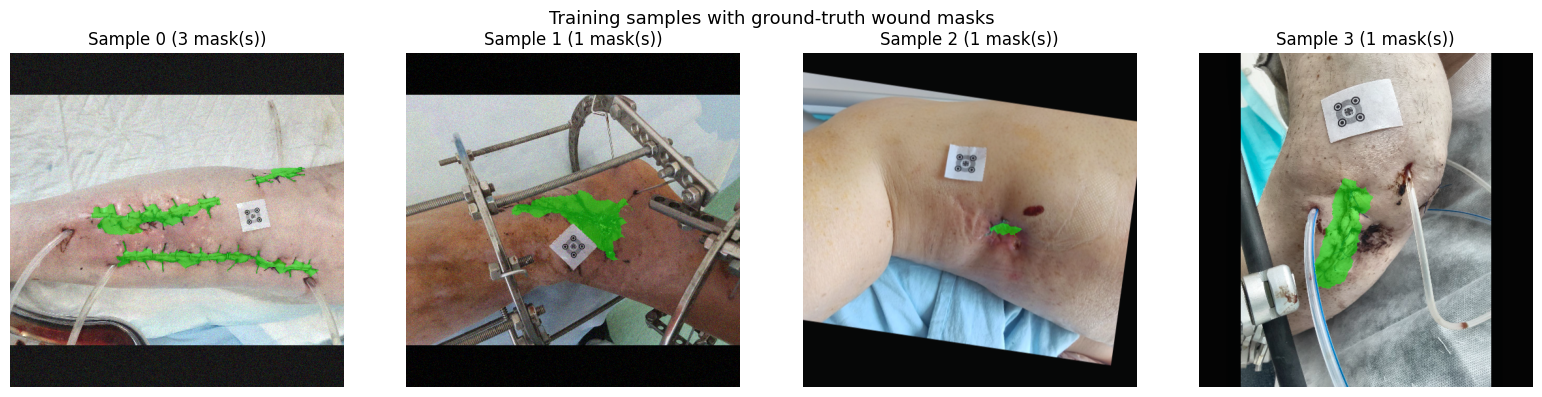

Model num_classes: 2

--- Startup label check ---
  Unique labels in batches: [1]
---------------------------

Optimizer: SGD  lr=0.001
Scheduler: StepLR  step_size=5  gamma=0.1


In [3]:
# ============================================================================
# 3.1 Visualize a few training samples with GT masks
# ============================================================================

NUM_VIS = 4
fig, axes = plt.subplots(1, NUM_VIS, figsize=(4 * NUM_VIS, 4))
if NUM_VIS == 1:
    axes = [axes]

for idx in range(min(NUM_VIS, len(train_dataset))):
    img_tensor, target = train_dataset[idx]
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = img_np * IMG_STD + IMG_MEAN
    img_np = np.clip(img_np, 0, 1)

    masks = target.get("masks")
    if masks is not None and masks.numel() > 0:
        combined = masks.sum(dim=0).clamp(0, 1).cpu().numpy()
        overlay = img_np.copy()
        overlay[combined > 0.5] = overlay[combined > 0.5] * 0.5 + np.array([0, 1, 0]) * 0.5
        img_np = overlay

    axes[idx].imshow(img_np)
    n_masks = masks.shape[0] if masks is not None else 0
    axes[idx].set_title(f"Sample {idx} ({n_masks} mask(s))")
    axes[idx].axis("off")

fig.suptitle("Training samples with ground-truth wound masks", fontsize=13)
fig.tight_layout()
plt.show()

# ============================================================================
# 3.2 Build model (background + wound = 2 classes)
# ============================================================================

base_ds = train_dataset.dataset if isinstance(train_dataset, torch.utils.data.Subset) else train_dataset
num_classes = base_ds.num_classes
print(f"Model num_classes: {num_classes}")
model = build_model(num_classes=num_classes, pretrained_backbone=True)
model.to(device)

print("\n--- Startup label check ---")
unique_labels = validate_dataset_labels(train_loader, num_classes, num_batches=5)
print(f"  Unique labels in batches: {unique_labels}")
print("---------------------------\n")

# ============================================================================
# 3.3 Optimizer and scheduler
# ============================================================================

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=CONFIG["lr"],
    momentum=0.9,
    weight_decay=0.0005,
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
class_mapping = getattr(base_ds, "class_mapping", {})

print(f"Optimizer: SGD  lr={CONFIG['lr']}")
print(f"Scheduler: StepLR  step_size=5  gamma=0.1")


## 4: Training Loop / Validation / Checkpoints


In [4]:
# ============================================================================
# 4.1 Training loop (from train_model.py)
# ============================================================================

results = {
    "train_losses": [],
    "val_losses": [],
    "metrics_per_epoch": [],
    "best_metric": 0.0,
    "best_epoch": 0,
    "best_bbox_AP50": 0.0,
    "best_segm_AP50": 0.0,
    "training_start": datetime.now().isoformat(),
    "training_end": None,
    "training_time": 0.0,
    "config": CONFIG,
    "num_classes": num_classes,
    "train_size": train_size,
    "val_size": val_size,
    "test_size": test_size,
    "device": str(device),
    "issues_found": "None noted.",
    "unresolved_issues": "None.",
}

best_combined_AP50 = 0.0
best_epoch = 0
early_stop_patience = CONFIG.get("early_stop_patience", 12)
epochs_without_improve = 0

print("=" * 60)
print("Starting Training")
print("=" * 60)
start_time = time.time()

try:
    for epoch in range(CONFIG["epochs"]):
        print(f"\nEpoch [{epoch + 1}/{CONFIG['epochs']}]")
        print("-" * 60)

        train_stats = train_one_epoch(
            model, optimizer, train_loader, device, epoch,
            scheduler=scheduler,
            scheduler_step_per_iter=False,
            loss_clip_max=CONFIG.get("loss_clip_max"),
            loss_skip_threshold=CONFIG.get("loss_skip_threshold"),
            skip_invalid_targets=CONFIG.get("skip_invalid_targets", True),
        )
        results["train_losses"].append(train_stats["total_loss"])

        val_stats = validate_one_epoch(
            model, val_loader, device,
            loss_clip_max=CONFIG.get("loss_clip_max"),
            loss_skip_threshold=CONFIG.get("loss_skip_threshold"),
            skip_invalid_targets=CONFIG.get("skip_invalid_targets", True),
        )
        results["val_losses"].append(val_stats["total_loss"])

        print("Evaluating metrics...")
        metrics = evaluate_metrics(model, val_loader, device)
        results["metrics_per_epoch"].append(metrics)

        combined_AP50 = metrics.get("combined_AP50", 0.0)
        bbox_AP50 = metrics.get("bbox_AP50", 0.0)
        segm_AP50 = metrics.get("segm_AP50", bbox_AP50)

        print(f"Train Loss: {train_stats['total_loss']:.4f} | Val Loss: {val_stats['total_loss']:.4f}")
        print(f"combined_AP50: {combined_AP50:.4f} | bbox_AP50: {bbox_AP50:.4f} | segm_AP50: {segm_AP50:.4f}")

        is_best = combined_AP50 > best_combined_AP50
        if is_best:
            best_combined_AP50 = combined_AP50
            best_epoch = epoch + 1
            results["best_metric"] = best_combined_AP50
            results["best_epoch"] = best_epoch
            results["best_bbox_AP50"] = bbox_AP50
            results["best_segm_AP50"] = segm_AP50
            epochs_without_improve = 0
            print(f"  NEW BEST! combined_AP50: {best_combined_AP50:.4f} (Epoch {best_epoch})")
            save_best_checkpoint(
                model, epoch=epoch + 1,
                best_combined_AP50=best_combined_AP50,
                bbox_AP50=bbox_AP50, segm_AP50=segm_AP50,
                config=CONFIG.copy(), class_mapping=class_mapping,
                output_dir=output_dir, filename="best_model.pth",
            )
        else:
            epochs_without_improve += 1

        save_last_checkpoint(
            model, optimizer, scheduler,
            epoch=epoch + 1, metrics=metrics,
            output_dir=output_dir, filename="last_checkpoint.pth",
            scaler=None,
        )

        scheduler.step()

        if early_stop_patience > 0 and epochs_without_improve >= early_stop_patience:
            print(f"Early stopping after {epochs_without_improve} epochs without improvement.")
            break

except KeyboardInterrupt:
    print("\n[WARNING] Training interrupted by user")
    results["interrupted"] = True
except Exception as e:
    print(f"\n[ERROR] {e}")
    import traceback
    traceback.print_exc()
    results["error"] = str(e)

training_time = time.time() - start_time
results["training_time"] = training_time
results["training_end"] = datetime.now().isoformat()

# ============================================================================
# 4.2 Load best model and run test evaluation
# ============================================================================

best_path = output_dir / "best_model.pth"
if best_path.exists():
    load_checkpoint(model, str(best_path))

print("\n" + "=" * 60)
print("Test Set Evaluation")
print("=" * 60)
test_metrics = None
try:
    test_metrics = evaluate_metrics(model, test_loader, device)
    results["test_metrics"] = test_metrics
    print("Test metrics:")
    for k, v in test_metrics.items():
        if isinstance(v, (int, float)):
            print(f"  {k}: {v:.4f}")
        else:
            print(f"  {k}: {v}")
except Exception as e:
    print(f"[WARNING] Test evaluation failed: {e}")
    results["test_metrics"] = {}

# ============================================================================
# 4.3 Save metrics summary and training history
# ============================================================================

metrics_summary = {
    "best_validation": {
        "combined_AP50": results["best_metric"],
        "bbox_AP50": results["best_bbox_AP50"],
        "segm_AP50": results["best_segm_AP50"],
        "best_epoch": results["best_epoch"],
    },
    "test": results.get("test_metrics", {}),
    "config": CONFIG,
}
with open(results_dir / "metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, indent=2, default=str)
print(f"\n  -> Metrics saved: {results_dir / 'metrics_summary.json'}")

history = {
    "train_losses": results["train_losses"],
    "val_losses": results["val_losses"],
    "metrics_per_epoch": results["metrics_per_epoch"],
    "config": CONFIG,
}
with open(output_dir / "training_history.json", "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2, default=str)
print(f"  -> History saved: {output_dir / 'training_history.json'}")

print("\n" + "=" * 60)
print("Training completed!")
print(f"Best combined_AP50: {best_combined_AP50:.4f} (epoch {best_epoch})")
print(f"Total time: {training_time:.2f}s ({training_time/60:.2f} min)")
print("=" * 60)


Starting Training

Epoch [1/50]
------------------------------------------------------------
Epoch: [0] [0/129] Loss: 7.1743
Epoch: [0] [10/129] Loss: 2.5186
Epoch: [0] [20/129] Loss: 2.0029
Epoch: [0] [30/129] Loss: 0.9331
Epoch: [0] [40/129] Loss: 0.9241
Epoch: [0] [50/129] Loss: 1.8529
Epoch: [0] [60/129] Loss: 0.7954
Epoch: [0] [70/129] Loss: 1.9848
Epoch: [0] [80/129] Loss: 0.7430
Epoch: [0] [90/129] Loss: 0.7446
Epoch: [0] [100/129] Loss: 1.1485
Epoch: [0] [110/129] Loss: 0.7890
Epoch: [0] [120/129] Loss: 0.8492
Evaluating metrics...
Using COCO evaluator...
[COCO eval] pred=(512,512) orig=(960,1280) bbox=1 segm=1
[COCO eval] Total: bbox=5225 segm=5225
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.11s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.007
 Average Precision  (AP) @[ IoU=0.50      

Saving training curves...
  -> E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\results\training_curves.png

Saving AP curves...
  -> ap_curves.png (bbox + segm + combined AP)


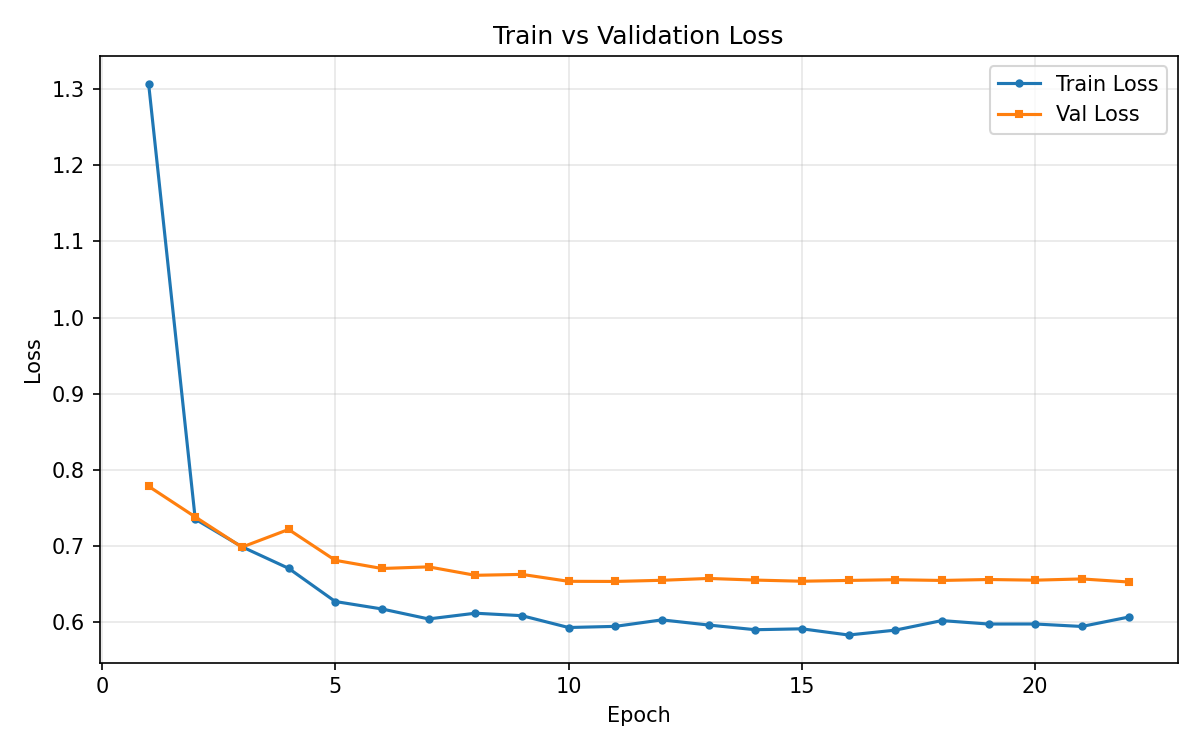

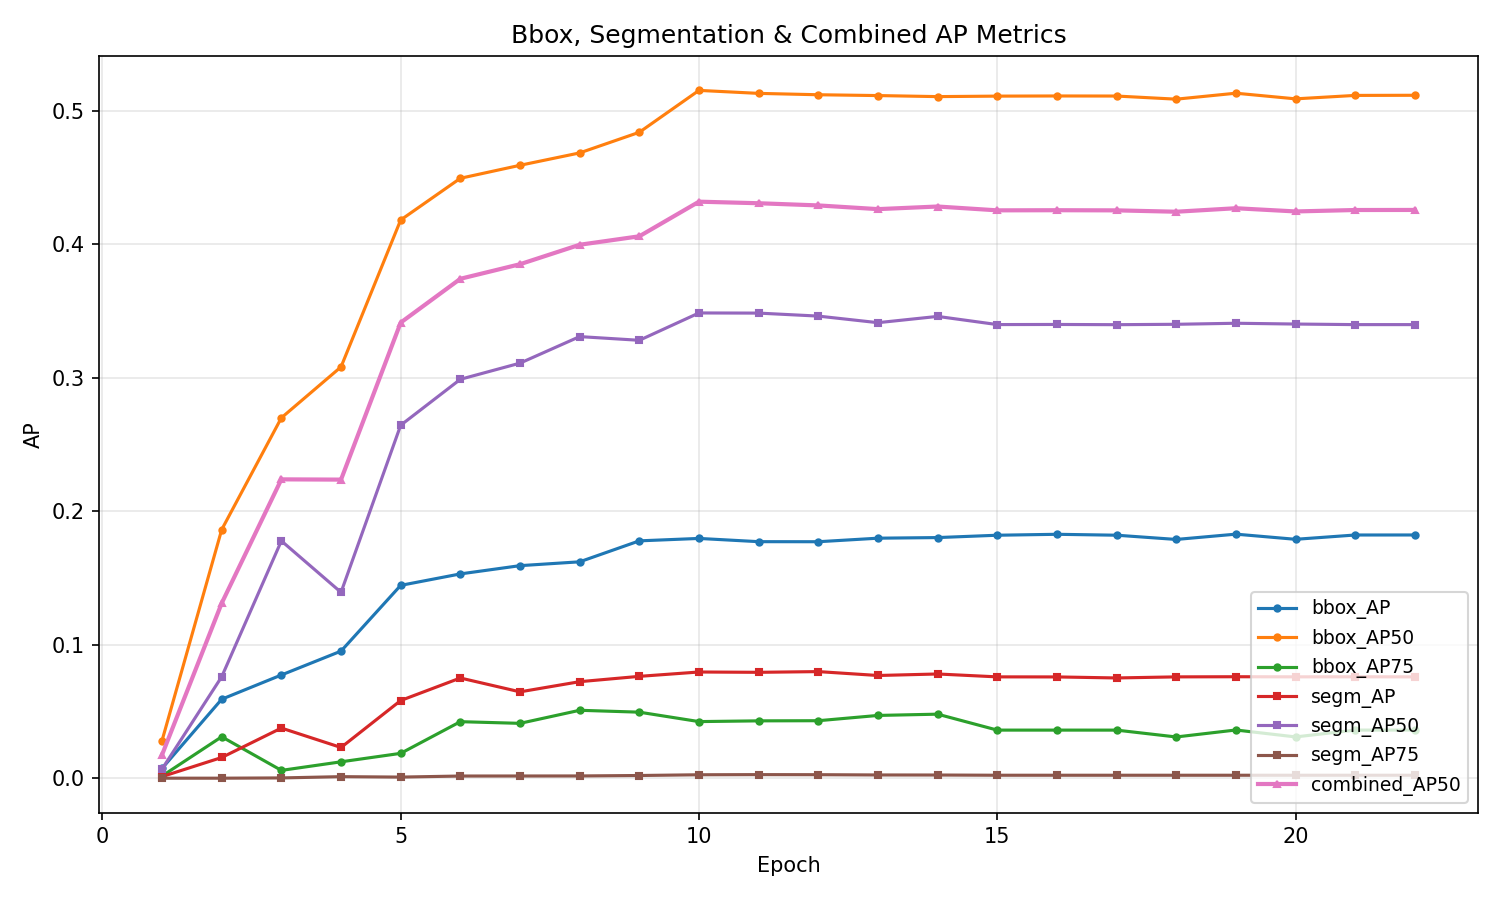

In [5]:
# ============================================================================
# Save training curves and AP curves to disk
# ============================================================================

print("Saving training curves...")
save_training_curves(
    results["train_losses"],
    results["val_losses"],
    results_dir / "training_curves.png",
)
print(f"  -> {results_dir / 'training_curves.png'}")

print("\nSaving AP curves...")
save_ap_curves(
    results["metrics_per_epoch"],
    results_dir,
)
print("  -> ap_curves.png (bbox + segm + combined AP)")

# ============================================================================
# Display all curves inline
# ============================================================================

display_results_curves(results_dir)

## 5: Qualitative Predictions / Reports / Summary


File: images/task_163_img_000186_infected.jpg
Wound area: 10544 px | Infection: Infected | Conf: 0.88


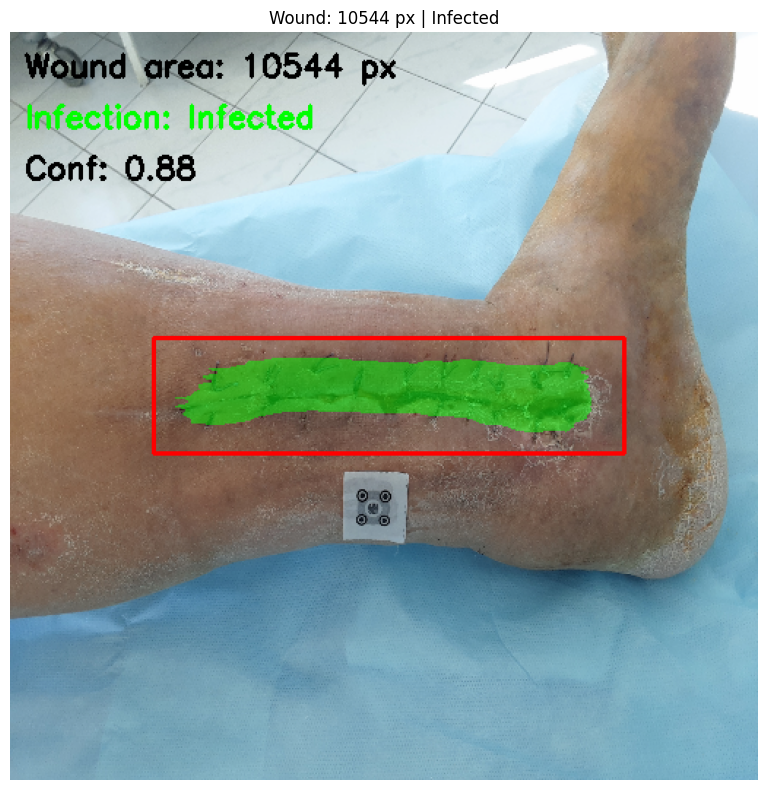


Results:
----------------------------------------
Detections: 20
Wound Area: 10736 px
Infection: Infected


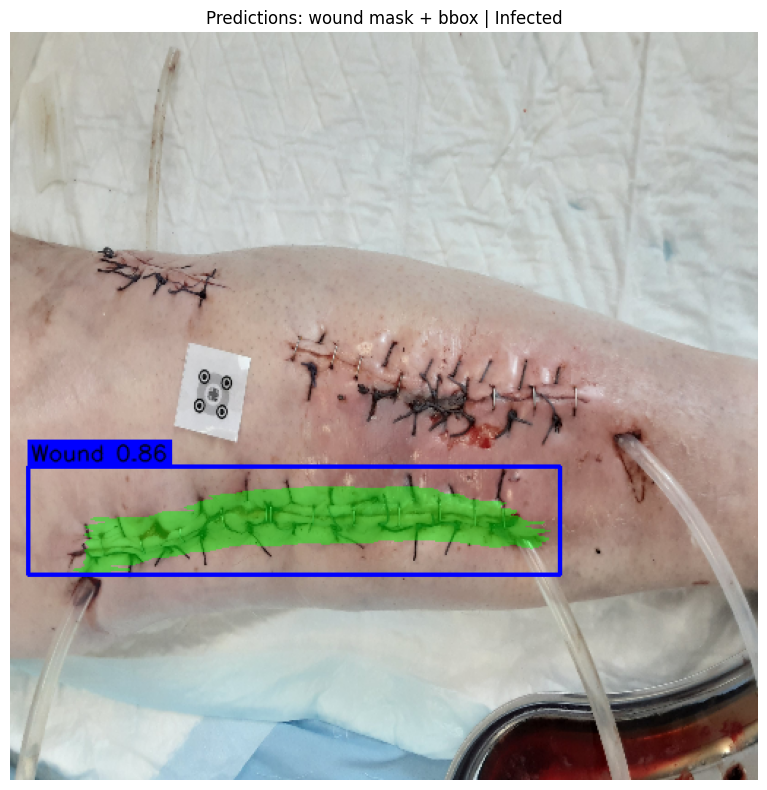

Saving qualitative predictions...
  -> 8 images saved to E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\results\predictions


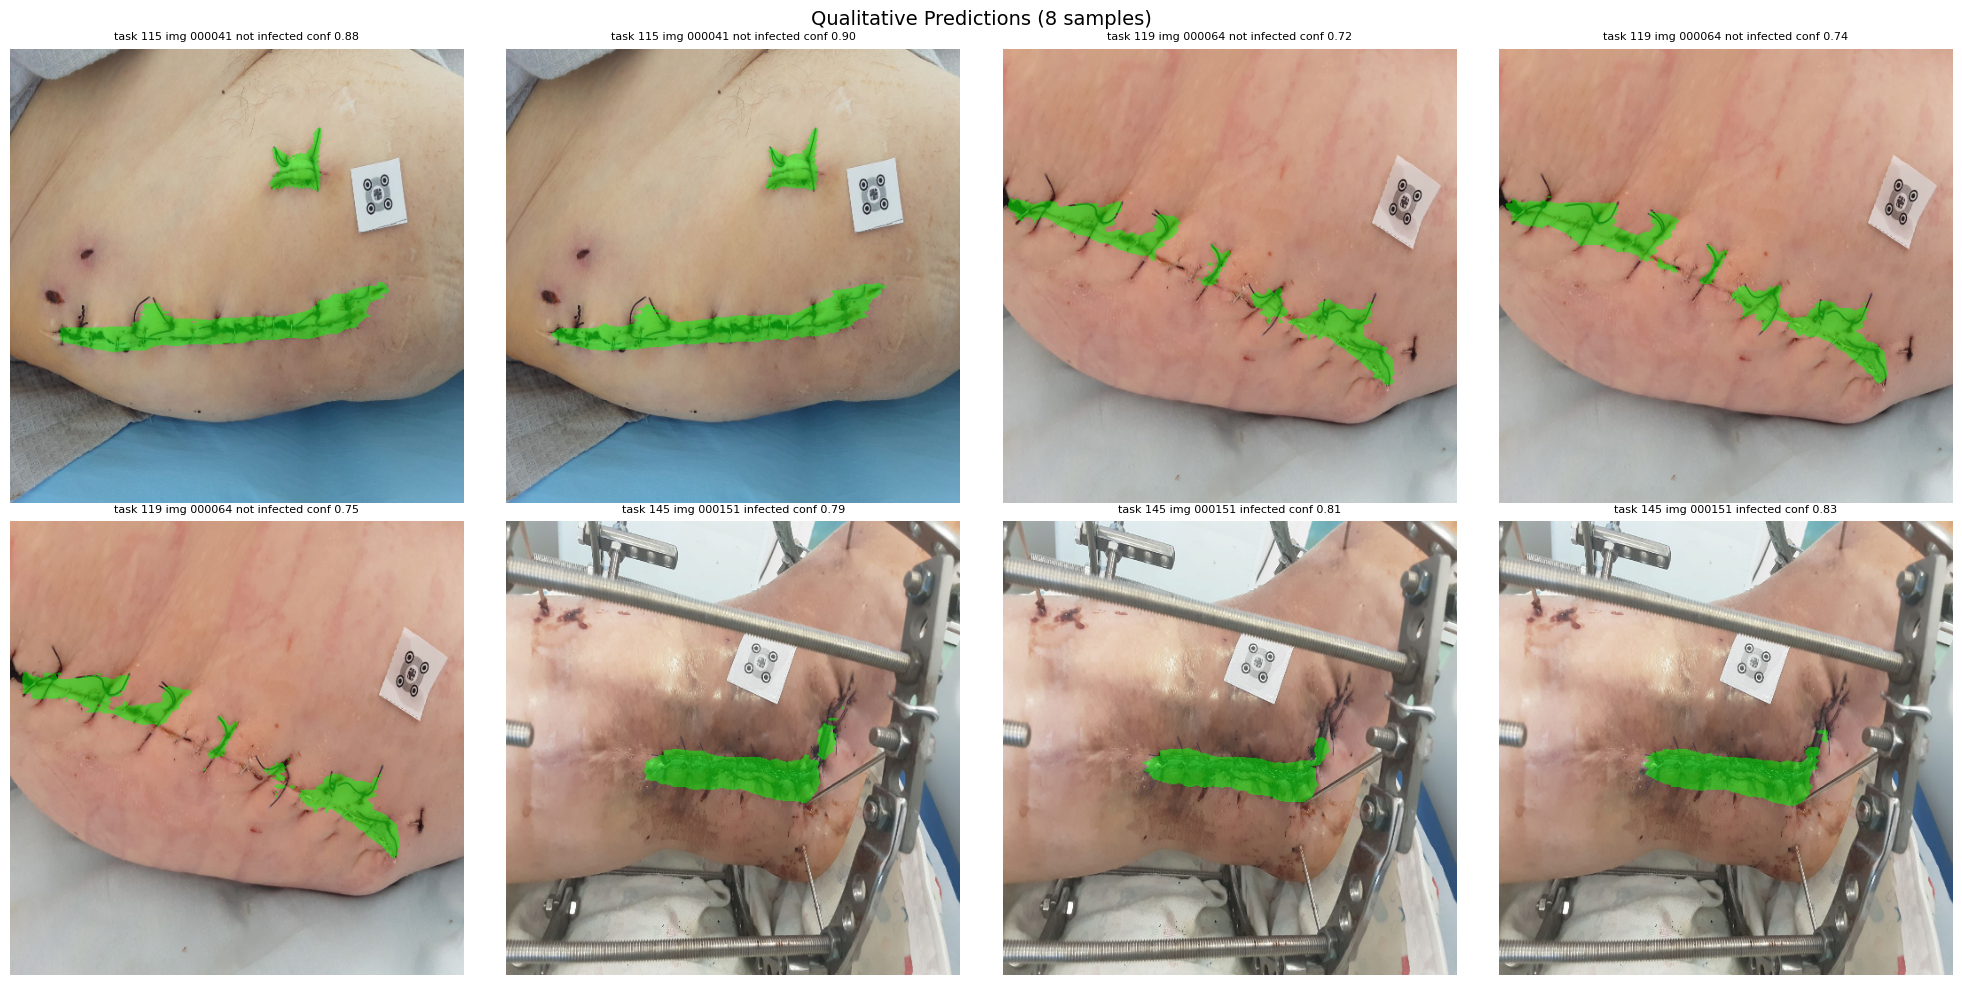


Generating wound-only reports...
  → Reports saved: E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\reports
  -> E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\reports\wound_only_training_report.md
  -> E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\reports\review_summary_for_chatgpt.md

WOUND-ONLY BASELINE -- FINAL SUMMARY
  Best combined_AP50 : 0.4319
  Best bbox_AP50     : 0.5153
  Best segm_AP50     : 0.3486
  Best epoch         : 10
  Training time      : 2256.4s (37.6 min)

Test set metrics:
    bbox_AP: 0.1515
    bbox_AP50: 0.4120
    bbox_AP75: 0.0605
    segm_AP: 0.0636
    segm_AP50: 0.2568
    segm_AP75: 0.0041
    combined_AP50: 0.3344

Output locations:
  Checkpoints : E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\checkpoints
  Results     : E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\results
  Reports     : E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\reports


In [6]:
# ============================================================================
# 5.1a Single-image: wound area, bounding box, infection status
# ============================================================================

SAMPLE_IDX = 0
img_result, pred_info = predict_single_image(
    model, test_loader, device,
    sample_index=SAMPLE_IDX,
    conf_thresh=CONFIG.get("conf_thresh_qualitative", 0.5),
)
print(f"File: {pred_info['file_name']}")
area_str = f"{pred_info['wound_area_cm2']} cm²" if pred_info.get('wound_area_cm2') else f"{pred_info['wound_area_px']} px"
print(f"Wound area: {area_str} | Infection: {pred_info['infection']} | Conf: {pred_info['confidence']:.2f}")

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
ax.set_title(f"Wound: {area_str} | {pred_info['infection']}")
ax.axis("off")
plt.tight_layout()
plt.show()

# ============================================================================
# 5.1b Predict from image path (like example: rectangle, area, visualization)
# ============================================================================

# Change path to image you want to predict on (relative to data_root)
image_path = "images/task_172_img_000211_infected.jpg"
CONF_THRESHOLD = 0.3
data_root = Path(CONFIG["data_root"])

result, predictions = predict_image(
    image_path, model, device,
    data_root=data_root,
    image_size=tuple(CONFIG["image_size"]),
    conf_threshold=CONF_THRESHOLD,
    marker_class_id=None,  # wound-only: no marker for cm²
)

print("\nResults:")
print("-" * 40)
print(f"Detections: {result['num_detections']}")
print(f"Wound Area: {result['wound_area_cm2']} cm²" if result['wound_area_cm2'] else f"Wound Area: {result['wound_area_px']} px")
print(f"Infection: {result['infection_label']}")

# Visualize (rectangle + mask overlay)
vis_img = visualize_prediction(
    image_path, predictions,
    data_root=data_root,
    image_size=tuple(CONFIG["image_size"]),
)
plt.figure(figsize=(10, 8))
plt.imshow(vis_img)
plt.title(f"Predictions: wound mask + bbox | {result['infection_label']}")
plt.axis("off")
plt.tight_layout()
plt.show()

# ============================================================================
# 5.1 Qualitative predictions (from train_model.py)
# ============================================================================

print("Saving qualitative predictions...")
n_saved = save_qualitative_predictions(
    model, test_loader, device,
    results_dir,
    num_samples=CONFIG.get("num_qualitative_samples", 8),
    conf_thresh=CONFIG.get("conf_thresh_qualitative", 0.5),
)
print(f"  -> {n_saved} images saved to {results_dir / 'predictions'}")

# Display predictions inline
display_results_predictions(results_dir)

# ============================================================================
# 5.2 Generate wound-only reports (from train_model.py)
# ============================================================================

print("\nGenerating wound-only reports...")
generate_wound_only_report(
    results=results,
    output_dir=reports_dir,
    test_metrics=results.get("test_metrics"),
)
print(f"  -> {reports_dir / 'wound_only_training_report.md'}")
print(f"  -> {reports_dir / 'review_summary_for_chatgpt.md'}")

# ============================================================================
# 5.3 Final summary
# ============================================================================

print("\n" + "=" * 60)
print("WOUND-ONLY BASELINE -- FINAL SUMMARY")
print("=" * 60)
print(f"  Best combined_AP50 : {results['best_metric']:.4f}")
print(f"  Best bbox_AP50     : {results['best_bbox_AP50']:.4f}")
print(f"  Best segm_AP50     : {results['best_segm_AP50']:.4f}")
print(f"  Best epoch         : {results['best_epoch']}")
print(f"  Training time      : {results['training_time']:.1f}s ({results['training_time']/60:.1f} min)")
if results.get("test_metrics"):
    print()
    print("Test set metrics:")
    for k, v in results["test_metrics"].items():
        if isinstance(v, (int, float)):
            print(f"    {k}: {v:.4f}")
print()
print("Output locations:")
print(f"  Checkpoints : {output_dir}")
print(f"  Results     : {results_dir}")
print(f"  Reports     : {reports_dir}")
print("=" * 60)


## 6: Review — Display Saved Curves and Predictions

Run this cell independently to view results from a previous training run without re-training.


TRAINING RESULTS SUMMARY

Best Validation (epoch 10):
  combined_AP50 : 0.4319
  bbox_AP50     : 0.5153
  segm_AP50     : 0.3486

Test Set:
  bbox_AP: 0.1515
  bbox_AP50: 0.4120
  bbox_AP75: 0.0605
  segm_AP: 0.0636
  segm_AP50: 0.2568
  segm_AP75: 0.0041
  combined_AP50: 0.3344


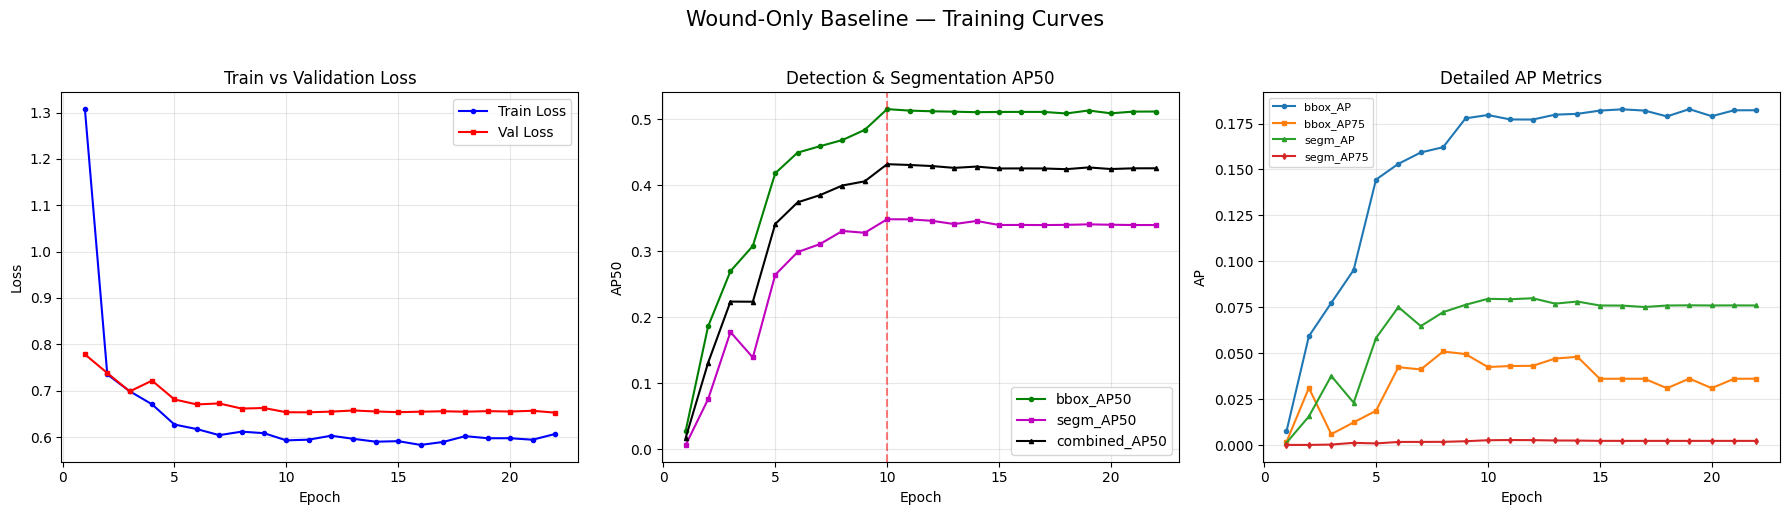


Total epochs trained: 22
Final train loss: 0.6064
Final val loss: 0.6526

SAVED CURVE IMAGES


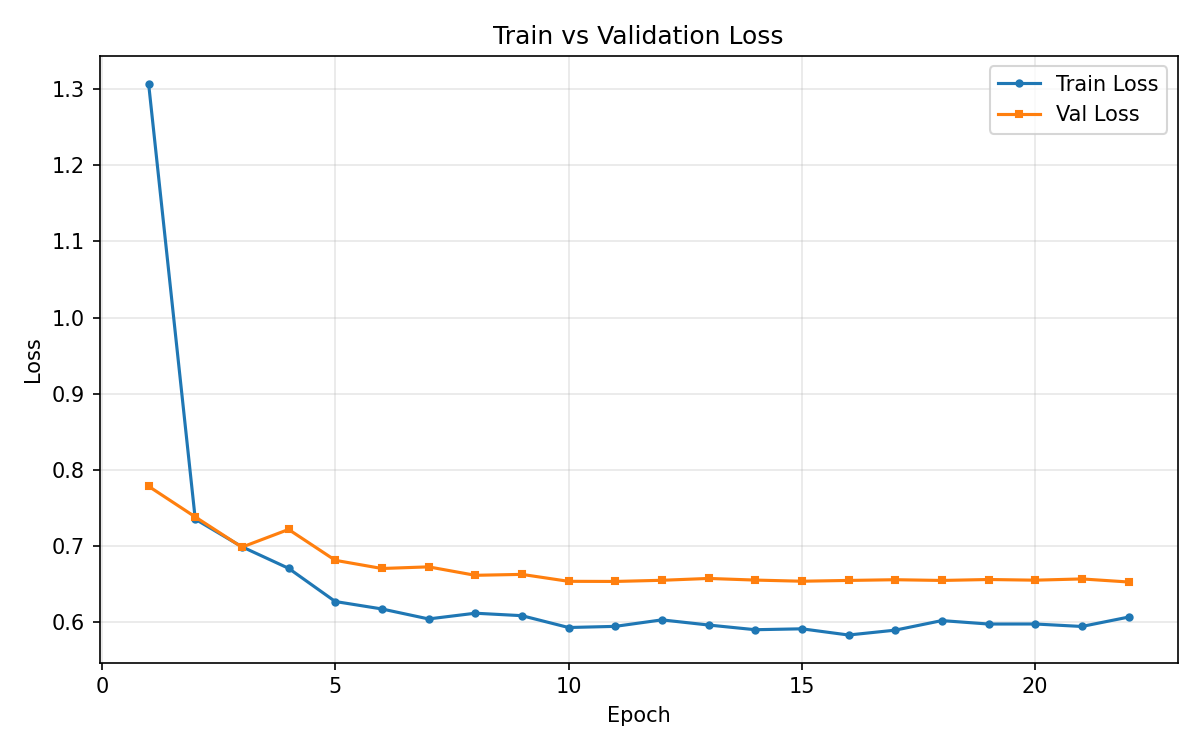

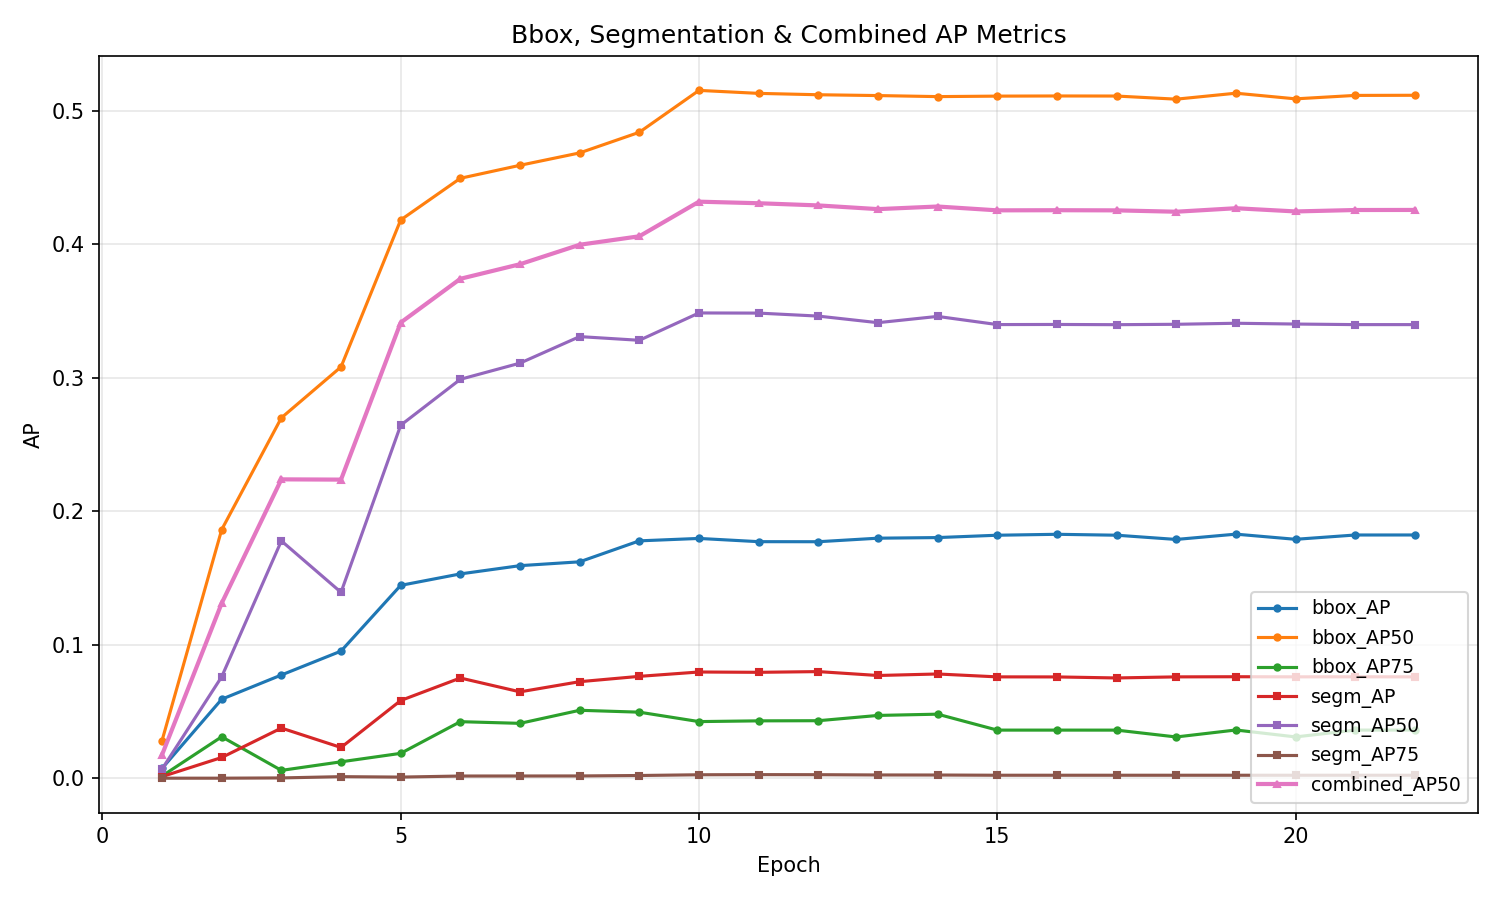


QUALITATIVE PREDICTIONS


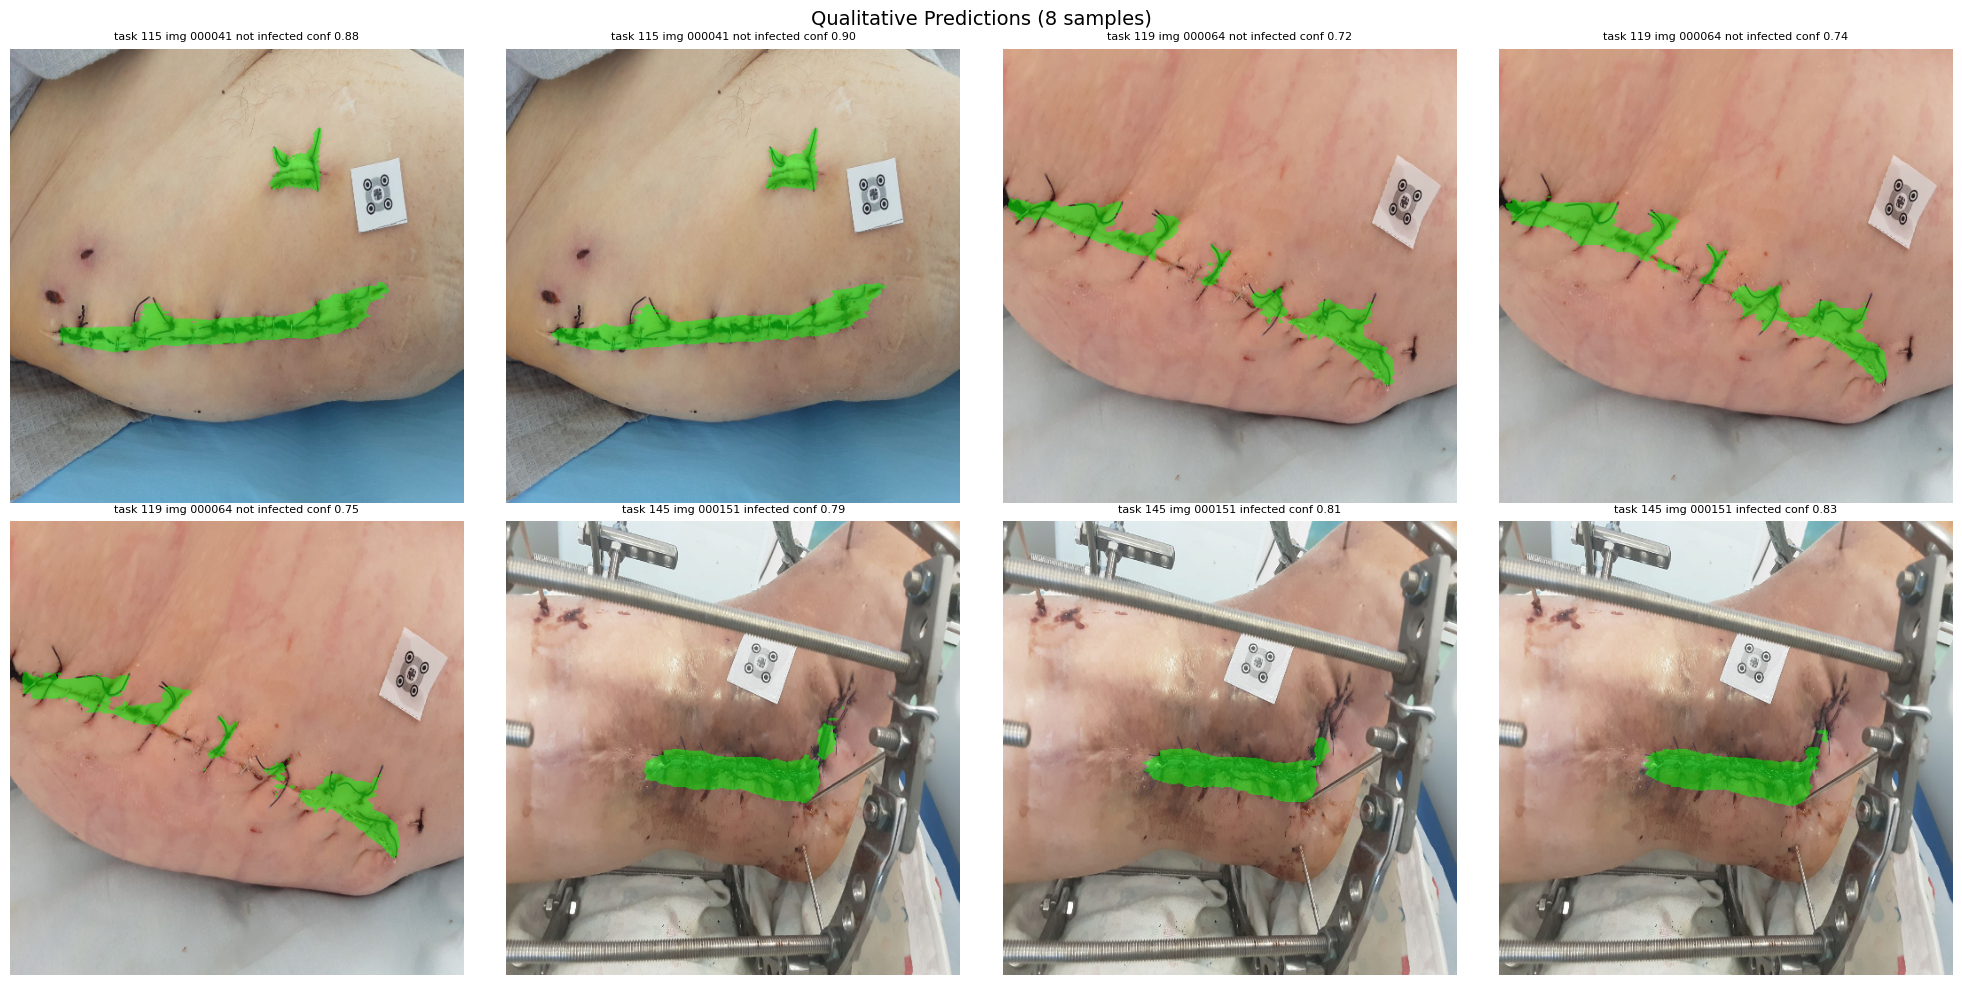


WOUND-ONLY TRAINING REPORT (preview)


# Wound-Only Segmentation Training Report

**Generated:** 2026-03-16 06:43:48

## Purpose

Single class: wound. Dataset: wound_focus_clean.

## Dataset

Train: E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\train_wound_only.json
Val: E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\val_wound_only.json
Test: E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\test_wound_only.json

## Model

Mask R-CNN ResNet-50-FPN, num_classes=2, image_size=(512, 512)

## Sizes

Train: 257, Val: 57, Test: 55

## Best Metrics

Best epoch: 10
combined_AP50: 0.4319
bbox_AP50: 0.5153
segm_AP50: 0.3486

Training time: 2256.45s

## Test Metrics

- bbox_AP: 0.1515
- bbox_AP50: 0.4120
- bbox_AP75: 0.0605
- segm_AP: 0.0636
- segm_AP50: 0.2568
- segm_AP75: 0.0041
- combined_AP50: 0.3344

See results/predictions/ for qualitative outputs.



In [7]:
%matplotlib inline
import json
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

SCRIPT_DIR = Path.cwd().resolve()
sys.path.insert(0, str(SCRIPT_DIR))
from train_model import display_results_curves, display_results_predictions

RESULTS_DIR = SCRIPT_DIR / "results"
REPORTS_DIR = SCRIPT_DIR / "reports"
CHECKPOINTS_DIR = SCRIPT_DIR / "checkpoints"

# ============================================================================
# 6.1 Training Metrics Summary
# ============================================================================

metrics_file = RESULTS_DIR / "metrics_summary.json"
if metrics_file.exists():
    with open(metrics_file, "r", encoding="utf-8") as f:
        metrics = json.load(f)

    print("=" * 60)
    print("TRAINING RESULTS SUMMARY")
    print("=" * 60)

    best = metrics.get("best_validation", {})
    print(f"\nBest Validation (epoch {best.get('best_epoch', '?')}):")
    print(f"  combined_AP50 : {best.get('combined_AP50', 0):.4f}")
    print(f"  bbox_AP50     : {best.get('bbox_AP50', 0):.4f}")
    print(f"  segm_AP50     : {best.get('segm_AP50', 0):.4f}")

    test = metrics.get("test", {})
    if test:
        print(f"\nTest Set:")
        for k, v in test.items():
            if isinstance(v, (int, float)):
                print(f"  {k}: {v:.4f}")
    print("=" * 60)
else:
    print("[WARN] No metrics_summary.json found. Run training first.")

# ============================================================================
# 6.2 Training History (loss over epochs)
# ============================================================================

history_file = CHECKPOINTS_DIR / "training_history.json"
if history_file.exists():
    with open(history_file, "r", encoding="utf-8") as f:
        history = json.load(f)

    train_losses = history.get("train_losses", [])
    val_losses = history.get("val_losses", [])
    metrics_per_epoch = history.get("metrics_per_epoch", [])

    if train_losses:
        epochs = range(1, len(train_losses) + 1)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Loss curves
        axes[0].plot(epochs, train_losses, "b-o", markersize=3, label="Train Loss")
        axes[0].plot(epochs, val_losses, "r-s", markersize=3, label="Val Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].set_title("Train vs Validation Loss")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # AP50 curves
        if metrics_per_epoch:
            bbox_ap50 = [m.get("bbox_AP50", 0) for m in metrics_per_epoch]
            segm_ap50 = [m.get("segm_AP50", 0) for m in metrics_per_epoch]
            combined = [m.get("combined_AP50", 0) for m in metrics_per_epoch]
            ep = range(1, len(metrics_per_epoch) + 1)

            axes[1].plot(ep, bbox_ap50, "g-o", markersize=3, label="bbox_AP50")
            axes[1].plot(ep, segm_ap50, "m-s", markersize=3, label="segm_AP50")
            axes[1].plot(ep, combined, "k-^", markersize=3, label="combined_AP50")
            axes[1].set_xlabel("Epoch")
            axes[1].set_ylabel("AP50")
            axes[1].set_title("Detection & Segmentation AP50")
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

            # Highlight best epoch
            best_idx = np.argmax(combined)
            axes[1].axvline(x=best_idx + 1, color="red", linestyle="--", alpha=0.5,
                            label=f"Best epoch {best_idx+1}")

            # Detailed AP breakdown
            bbox_ap = [m.get("bbox_AP", 0) for m in metrics_per_epoch]
            segm_ap = [m.get("segm_AP", 0) for m in metrics_per_epoch]
            bbox_ap75 = [m.get("bbox_AP75", 0) for m in metrics_per_epoch]
            segm_ap75 = [m.get("segm_AP75", 0) for m in metrics_per_epoch]

            axes[2].plot(ep, bbox_ap, "-o", markersize=3, label="bbox_AP")
            axes[2].plot(ep, bbox_ap75, "-s", markersize=3, label="bbox_AP75")
            axes[2].plot(ep, segm_ap, "-^", markersize=3, label="segm_AP")
            axes[2].plot(ep, segm_ap75, "-d", markersize=3, label="segm_AP75")
            axes[2].set_xlabel("Epoch")
            axes[2].set_ylabel("AP")
            axes[2].set_title("Detailed AP Metrics")
            axes[2].legend(fontsize=8)
            axes[2].grid(True, alpha=0.3)

        fig.suptitle("Wound-Only Baseline — Training Curves", fontsize=15, y=1.02)
        fig.tight_layout()
        plt.show()

        print(f"\nTotal epochs trained: {len(train_losses)}")
        print(f"Final train loss: {train_losses[-1]:.4f}")
        print(f"Final val loss: {val_losses[-1]:.4f}")
else:
    print("[WARN] No training_history.json found.")

# ============================================================================
# 6.3 Saved Curve Images
# ============================================================================

print("\n" + "=" * 60)
print("SAVED CURVE IMAGES")
print("=" * 60)
display_results_curves(RESULTS_DIR)

# ============================================================================
# 6.4 Qualitative Predictions
# ============================================================================

print("\n" + "=" * 60)
print("QUALITATIVE PREDICTIONS")
print("=" * 60)
display_results_predictions(RESULTS_DIR)

# ============================================================================
# 6.5 Report Preview
# ============================================================================

report_file = REPORTS_DIR / "wound_only_training_report.md"
if report_file.exists():
    print("\n" + "=" * 60)
    print("WOUND-ONLY TRAINING REPORT (preview)")
    print("=" * 60)
    text = report_file.read_text(encoding="utf-8")
    display(Markdown(text))